In [6]:
import pandas as pd
import numpy as np

In [84]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\Vehicle_Insurance..csv")

In [85]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28,0,> 2 Years,Yes,40454,26,217,1
1,2,Male,76,1,3,0,1-2 Year,No,33536,26,183,0
2,3,Male,47,1,28,0,> 2 Years,Yes,38294,26,27,1
3,4,Male,21,1,11,1,< 1 Year,No,28619,152,203,0
4,5,Female,29,1,41,1,< 1 Year,No,27496,152,39,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    381109 non-null  int64 
 1   Gender                381109 non-null  object
 2   Age                   381109 non-null  int64 
 3   Driving_License       381109 non-null  int64 
 4   Region_Code           381109 non-null  int64 
 5   Previously_Insured    381109 non-null  int64 
 6   Vehicle_Age           381109 non-null  object
 7   Vehicle_Damage        381109 non-null  object
 8   Annual_Premium        381109 non-null  int64 
 9   Policy_Sales_Channel  381109 non-null  int64 
 10  Vintage               381109 non-null  int64 
 11  Response              381109 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 34.9+ MB


In [87]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [88]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [89]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

# 2. DATA CLEANING 

In [90]:
# Check missing values
df.isnull().sum()

# Convert categorical
df['Gender'] = df['Gender'].astype('category')
df['Vehicle_Age'] = df['Vehicle_Age'].astype('category')
df['Vehicle_Damage'] = df['Vehicle_Damage'].astype('category')

# 3. Data Visualization:

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

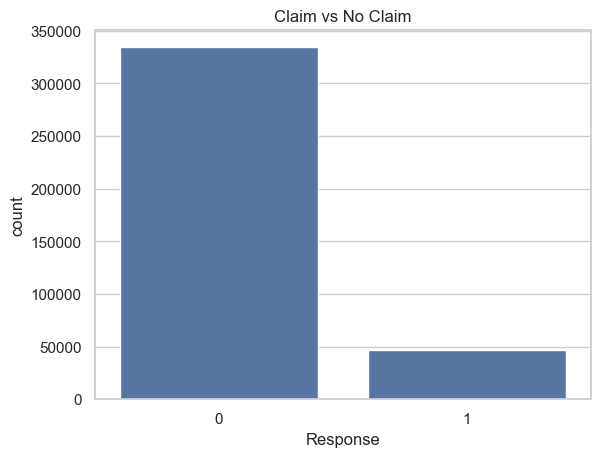

In [92]:
sns.countplot(x='Response', data=df)
plt.title("Claim vs No Claim")
plt.show()

# #  4.Feature Analysis (Core Insights)
👤 Age vs Claims  

In [93]:
df['Response'].value_counts()
df['Response'].value_counts(normalize=True)

Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64

# 5. Age Distribution:

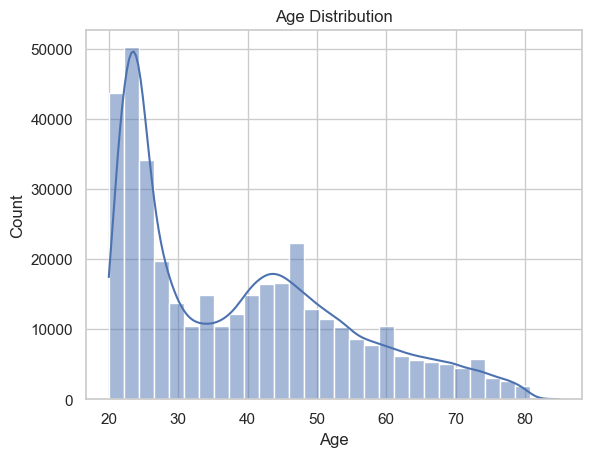

In [94]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# 6'Premium Analysis

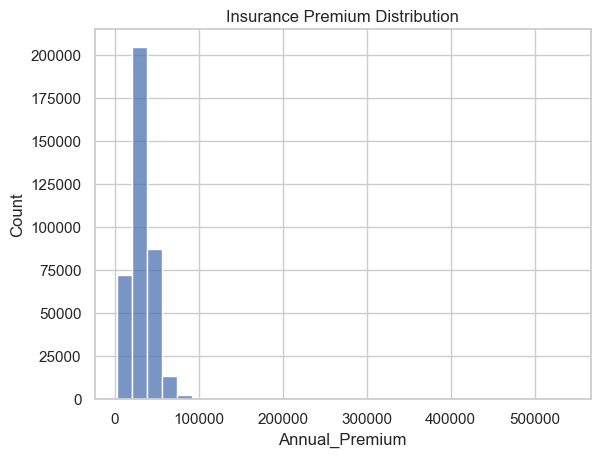

In [95]:
sns.histplot(df['Annual_Premium'], bins=30)
plt.title("Insurance Premium Distribution")
plt.show()

<Axes: xlabel='Annual_Premium', ylabel='Count'>

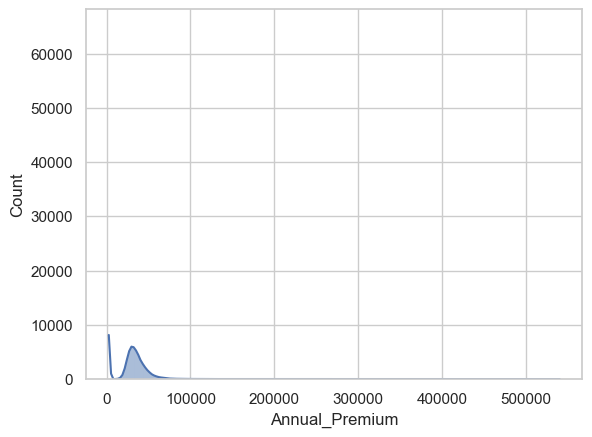

In [96]:
sns.histplot(df['Annual_Premium'], kde=True)

# 7. Claim Frequency Analysis

In [97]:
df['Response'].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

# 8.Gender Analysis:

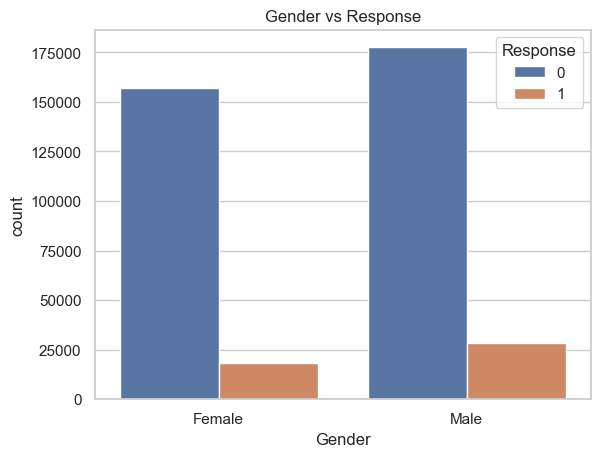

In [98]:
sns.countplot(x='Gender', hue='Response', data=df)
plt.title('Gender vs Response')
plt.show()

# 9.Vehicle Age and Claims:

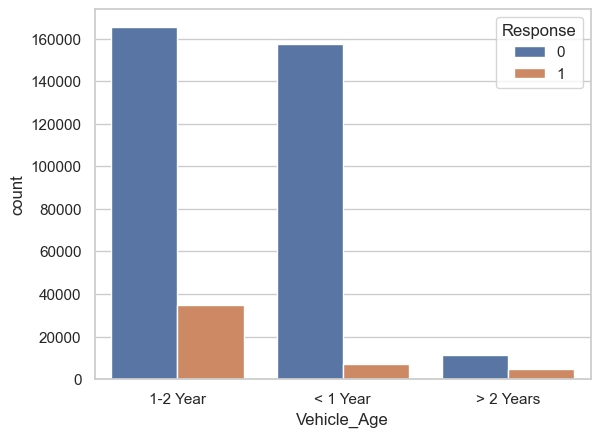

In [99]:
sns.countplot(x='Vehicle_Age', hue='Response', data=df)
plt.show()

# 10. Region-wise Analysis

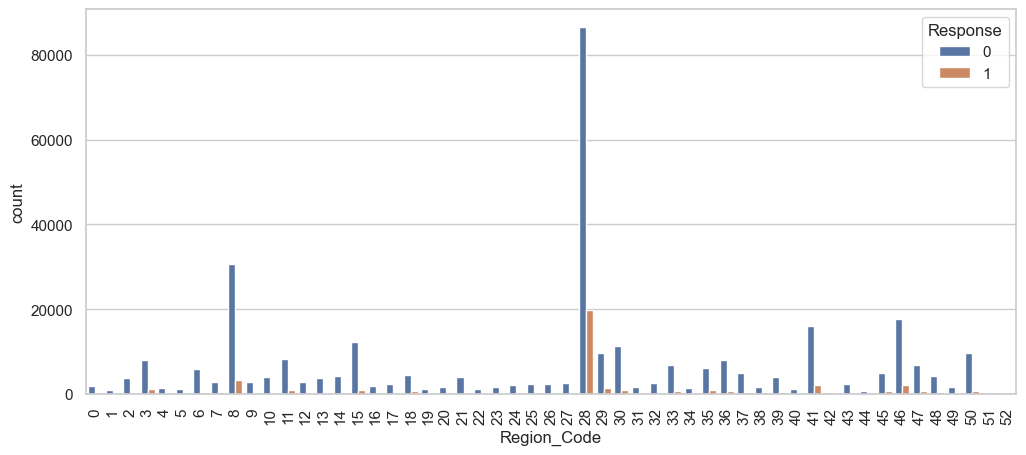

In [100]:
plt.figure(figsize=(12,5))
sns.countplot(x='Region_Code', hue='Response', data=df)
plt.xticks(rotation=90)
plt.show()

# 11.Policy Analysis

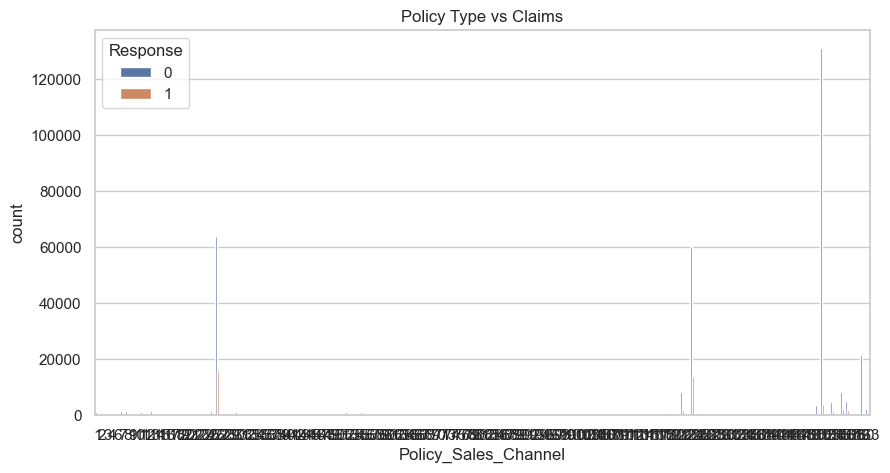

In [101]:
plt.figure(figsize=(10,5))
sns.countplot(x='Policy_Sales_Channel', hue='Response', data=df)
plt.title("Policy Type vs Claims")
plt.show()

In [102]:
policy_claim_rate = df.groupby('Policy_Sales_Channel')['Response'].mean()
policy_claim_rate.sort_values(ascending=False)

Policy_Sales_Channel
123    1.000000
43     1.000000
27     0.333333
28     0.333333
36     0.326923
         ...   
112    0.000000
99     0.000000
137    0.000000
50     0.000000
84     0.000000
Name: Response, Length: 155, dtype: float64

# 12. Claim Frequency by Vehicle Damage:

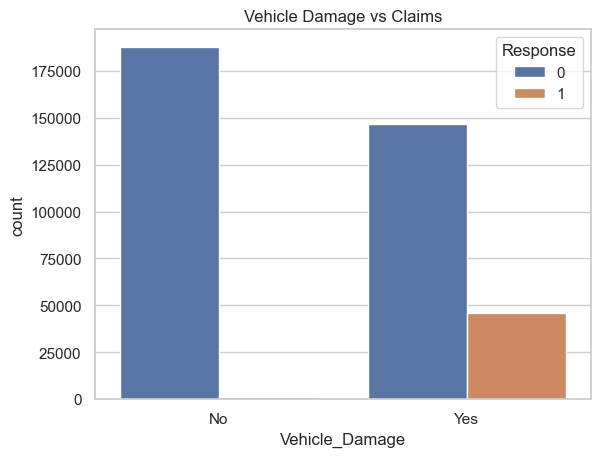

In [103]:
sns.countplot(x='Vehicle_Damage', hue='Response', data=df)
plt.title("Vehicle Damage vs Claims")
plt.show()

# 13. Customer Loyalty Analysis

In [104]:
loyalty_claim = df.groupby('Previously_Insured')['Response'].mean()
print(loyalty_claim)

Previously_Insured
0    0.225454
1    0.000905
Name: Response, dtype: float64


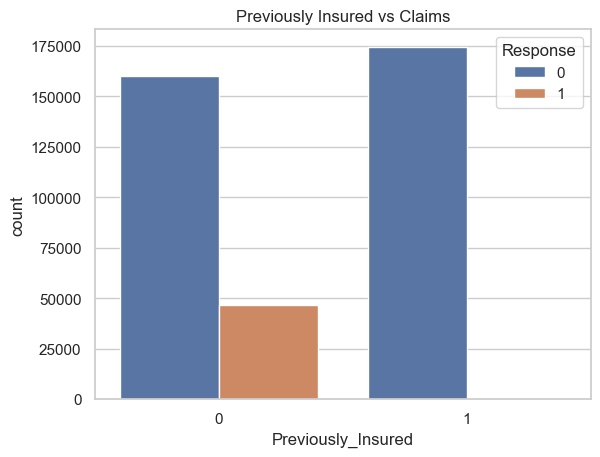

In [105]:
sns.countplot(x='Previously_Insured', hue='Response', data=df)
plt.title("Previously Insured vs Claims")
plt.show()

# 14. Time Analysis

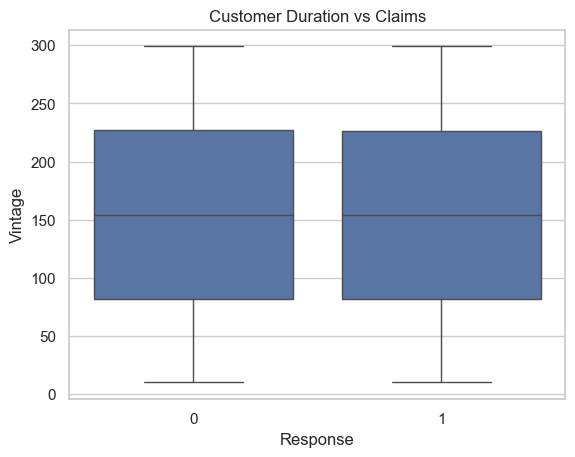

In [106]:
sns.boxplot(x='Response', y='Vintage', data=df)
plt.title("Customer Duration vs Claims")
plt.show()